In [5]:
import pandas as pd
import numpy as np

def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max: df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max: df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max: df[col] = df[col].astype(np.int32)
                else: df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max: df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max: df[col] = df[col].astype(np.float32)
                else: df[col] = df[col].astype(np.float64)
    return df

print("Loading data...")
df_tx = pd.read_parquet('train_transaction_optimized.parquet')
df_id = pd.read_csv('train_identity.csv')
df_id = reduce_mem_usage(df_id)

# FIX: Upcast TransactionAmt to prevent float16 rounding loss on cents
if 'TransactionAmt' in df_tx.columns and df_tx['TransactionAmt'].dtype == 'float16':
    df_tx['TransactionAmt'] = df_tx['TransactionAmt'].astype(np.float32)
    print("Upcasted TransactionAmt to float32 to preserve cent precision.")

print("Data loaded and optimized!")

Loading data...
Upcasted TransactionAmt to float32 to preserve cent precision.
Data loaded and optimized!


In [6]:
def sparse_filter(df, threshold=0.75, name="Table"):
    missing_rates = df.isnull().mean()
    cols_to_drop = missing_rates[missing_rates > threshold].index.tolist()
    print(f"[{name}] Dropped {len(cols_to_drop)} sparse columns.")
    return df.drop(columns=cols_to_drop)

# FIX: Capture the baseline identity IDs BEFORE filtering
identity_ids = set(df_id['TransactionID'])

# 1. Filter each independently
df_tx_cleaned = sparse_filter(df_tx, threshold=0.75, name="Transactions")
df_id_cleaned = sparse_filter(df_id, threshold=0.75, name="Identity")

# 2. Merge them together
df = df_tx_cleaned.merge(df_id_cleaned, on='TransactionID', how='left')

# 3. FIX: Bulletproof 'has_identity' signal using the pre-filter set
df['has_identity'] = df['TransactionID'].isin(identity_ids).astype(np.int8)

# 4. Add explicit missingness flags for numeric identity columns
id_num_cols = [c for c in df_id_cleaned.select_dtypes(include=['number']).columns if c != 'TransactionID']
for col in id_num_cols:
    df[f"{col}_was_missing"] = df[col].isnull().astype(np.int8)

print(f"Final merged dataset shape: {df.shape}")

[Transactions] Dropped 168 sparse columns.
[Identity] Dropped 9 sparse columns.
Final merged dataset shape: (590540, 274)


In [7]:
# 1. Sort everything chronologically FIRST
df = df.sort_values('TransactionDT').reset_index(drop=True)

# 2. Separate Target (y) and Features (X)
y = df['isFraud']
X = df.drop(columns=['isFraud', 'TransactionID', 'TransactionDT'])

# 3. Split 80/20 strictly by time
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("--- Time-Based Split Successful ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# FIX: Sanity check to ensure fraud rate didn't completely degenerate across time
print(f"Train fraud rate: {y_train.mean() * 100:.2f}%")
print(f"Test fraud rate: {y_test.mean() * 100:.2f}%")

--- Time-Based Split Successful ---
X_train shape: (472432, 271)
X_test shape: (118108, 271)
Train fraud rate: 3.51%
Test fraud rate: 3.44%


In [8]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# FIX: Sanity check datatypes so `remainder='drop'` doesn't silently kill booleans
print("Data types entering the pipeline:")
print(X_train.dtypes.value_counts())

# 1. Detect final column types based on the training data
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nRouting {len(numeric_cols)} numeric and {len(categorical_cols)} categorical features.")

# 2. Setup Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# 3. Build the orchestrator
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ], 
    remainder='drop'
)

print("\nPipeline architecture successfully constructed.")


Data types entering the pipeline:
float16    205
object      28
float32     20
int8        17
int16        1
Name: count, dtype: int64

Routing 243 numeric and 28 categorical features.

Pipeline architecture successfully constructed.


In [9]:
print(X_train['TransactionAmt'].dtype, X_train['TransactionAmt'].head(10))

float32 0     68.5
1     29.0
2     59.0
3     50.0
4     50.0
5     49.0
6    159.0
7    422.5
8     15.0
9    117.0
Name: TransactionAmt, dtype: float32


In [10]:
print(y_train.mean(), y_test.mean())

0.03513521522674162 0.034409184813899145


In [11]:
# Fit and transforming the training data
print("Fitting the pipeline on training data")
X_train_processed = preprocessor.fit_transform(X_train)
print("Training data transformed successfully.")

# Apply the same preprocessing to the test data
print("Transforming test data...")
X_test_processed = preprocessor.transform(X_test)
print("Test data transformed successfully.")

# Checking the final shapes
print(f"\nFinal Train Array Shape: {X_train_processed.shape}")
print(f"Final Test Array Shape: {X_test_processed.shape}")

Fitting the pipeline on training data
Training data transformed successfully.
Transforming test data...
Test data transformed successfully.

Final Train Array Shape: (472432, 271)
Final Test Array Shape: (118108, 271)


In [12]:
assert X_train_processed.shape[1] == X_test_processed.shape[1]

In [13]:
import xgboost as xgb
import time
from sklearn.metrics import average_precision_score, roc_auc_score

# 1. Carve out a validation set from the training data (leave test untouched)
val_split_idx = int(len(X_train_processed) * 0.9)
X_tr, X_val = X_train_processed[:val_split_idx], X_train_processed[val_split_idx:]
y_tr, y_val = y_train.iloc[:val_split_idx], y_train.iloc[val_split_idx:]

# 2. Calculate imbalance ratio to penalize missed fraud
safe_count = (y_tr == 0).sum()
fraud_count = (y_tr == 1).sum()
imbalance_ratio = safe_count / fraud_count
print(f"Safe: {safe_count} | Fraud: {fraud_count} | Imbalance Ratio: {imbalance_ratio:.2f}:1\n")

# 3. Setup XGBoost with early stopping and regularization
baseline_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,
    subsample=0.8,           # Prevents relying too heavily on specific rows
    colsample_bytree=0.8,    # Prevents relying too heavily on specific columns
    tree_method='hist',      # Speeds up training massively
    eval_metric='aucpr',     
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

# 4. Train the model (watching validation PR-AUC to prevent overfitting)
print("Training XGBoost with early stopping...")
start_time = time.time()
baseline_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f"\nTraining complete in {time.time() - start_time:.1f}s")
print(f"Best iteration: {baseline_model.best_iteration} (out of 1000 max)")

# 5. Final blind test evaluation (only do this once!)
y_pred_proba = baseline_model.predict_proba(X_test_processed)[:, 1]

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n--- Held-out Test Set (final report numbers) ---")
print(f"PR-AUC:  {pr_auc:.4f}  <- decision metric")
print(f"ROC-AUC: {roc_auc:.4f}")

Safe: 410243 | Fraud: 14945 | Imbalance Ratio: 27.45:1

Training XGBoost with early stopping...
[0]	validation_0-aucpr:0.31515
[50]	validation_0-aucpr:0.45910
[100]	validation_0-aucpr:0.48510
[150]	validation_0-aucpr:0.50187
[200]	validation_0-aucpr:0.51547
[250]	validation_0-aucpr:0.52621
[300]	validation_0-aucpr:0.53275
[350]	validation_0-aucpr:0.54021
[400]	validation_0-aucpr:0.54677
[450]	validation_0-aucpr:0.55237
[500]	validation_0-aucpr:0.55507
[550]	validation_0-aucpr:0.55811
[600]	validation_0-aucpr:0.56279
[650]	validation_0-aucpr:0.56801
[700]	validation_0-aucpr:0.56994
[750]	validation_0-aucpr:0.57268
[800]	validation_0-aucpr:0.57596
[850]	validation_0-aucpr:0.57755
[900]	validation_0-aucpr:0.57928
[950]	validation_0-aucpr:0.57988
[984]	validation_0-aucpr:0.57914

Training complete in 114.7s
Best iteration: 954 (out of 1000 max)

--- Held-out Test Set (final report numbers) ---
PR-AUC:  0.4948  <- decision metric
ROC-AUC: 0.8943


In [14]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


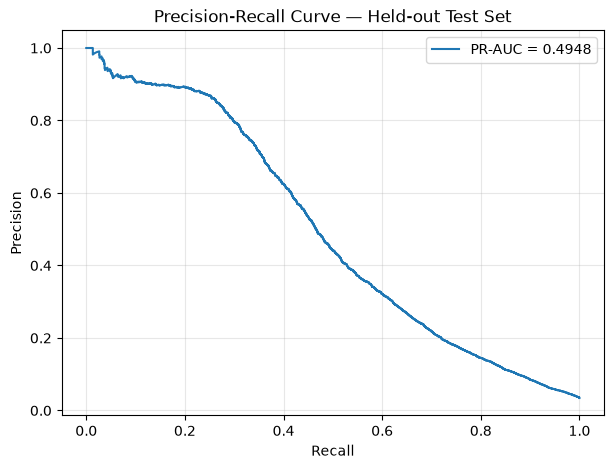

Recall≈0.50 → Precision=0.442, threshold=0.718
Recall≈0.60 → Precision=0.322, threshold=0.589
Recall≈0.70 → Precision=0.218, threshold=0.441
Recall≈0.80 → Precision=0.145, threshold=0.297


In [15]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Held-out Test Set')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# find a few concrete threshold candidates
for target_recall in [0.5, 0.6, 0.7, 0.8]:
    idx = (abs(recall - target_recall)).argmin()
    print(f"Recall≈{recall[idx]:.2f} → Precision={precision[idx]:.3f}, threshold={thresholds[idx]:.3f}")

In [16]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. Pull the ORIGINAL (untransformed) TransactionAmt for the test rows
# Align the indices so they match perfectly with y_test and y_pred_proba
test_amounts = X_test['TransactionAmt'].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# 2. Define the candidate thresholds to test
candidates = [0.718, 0.589, 0.441, 0.297]
results = []

for t in candidates:
    # Convert probabilities to hard 0/1 decisions based on the threshold
    y_pred = (y_pred_proba >= t).astype(int)
    
    # Calculate True Negatives, False Positives, False Negatives, True Positives
    tn, fp, fn, tp = confusion_matrix(y_test_reset, y_pred).ravel()

    # FN Cost: The actual dollar amount of fraud that slipped through
    fn_amount = test_amounts[(y_test_reset == 1) & (pd.Series(y_pred) == 0)].sum()

    # FP Cost: The labor cost of human analysts reviewing false alarms
    # (Placeholder: ₹50 per review. State clearly in your README this is an estimate)
    fp_review_cost = 50
    fp_total_cost = fp * fp_review_cost
    
    # The ultimate business metric: How much money did this threshold cost us?
    total_loss = fn_amount + fp_total_cost

    results.append({
        'Threshold': t, 
        'Recall': f"{tp/(tp+fn)*100:.1f}%", 
        'Precision': f"{tp/(tp+fp)*100:.1f}%",
        'TP': tp, 
        'FP': fp, 
        'FN': fn, 
        'TN': tn,
        'Fraud_Missed_$ (FN)': fn_amount,
        'Review_Cost_$ (FP)': fp_total_cost,
        'Total_Loss_$': total_loss
    })

# 3. Format and display the results
cost_df = pd.DataFrame(results)

# Sort by the lowest total loss so the winning threshold is at the top
cost_df = cost_df.sort_values('Total_Loss_$').reset_index(drop=True)

print("--- Business Cost Matrix Analysis ---")
print(cost_df.to_string(index=False))

--- Business Cost Matrix Analysis ---
 Threshold Recall Precision   TP    FP   FN     TN  Fraud_Missed_$ (FN)  Review_Cost_$ (FP)  Total_Loss_$
     0.718  50.0%     44.2% 2033  2569 2031 111475        334958.968750              128450  4.634090e+05
     0.589  60.0%     32.2% 2438  5139 1626 108905        250237.062500              256950  5.071871e+05
     0.441  70.0%     21.8% 2843 10170 1221 103874        180830.968750              508500  6.893310e+05
     0.297  80.1%     14.5% 3254 19228  810  94816        110483.171875              961400  1.071883e+06


In [17]:
print([x for x in globals() if not x.startswith('_')])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'xgb', 'time', 'average_precision_score', 'roc_auc_score', 'pd', 'np', 'reduce_mem_usage', 'df_tx', 'df_id', 'sparse_filter', 'identity_ids', 'df_tx_cleaned', 'df_id_cleaned', 'df', 'id_num_cols', 'col', 'y', 'X', 'split_idx', 'X_train', 'X_test', 'y_train', 'y_test', 'SimpleImputer', 'Pipeline', 'ColumnTransformer', 'OrdinalEncoder', 'numeric_cols', 'categorical_cols', 'numeric_transformer', 'categorical_transformer', 'preprocessor', 'X_train_processed', 'X_test_processed', 'val_split_idx', 'X_tr', 'X_val', 'y_tr', 'y_val', 'safe_count', 'fraud_count', 'imbalance_ratio', 'baseline_model', 'start_time', 'y_pred_proba', 'pr_auc', 'roc_auc', 'precision_recall_curve', 'plt', 'precision', 'recall', 'thresholds', 'target_recall', 'idx', 'confusion_matrix', 'test_amounts', 'y_test_reset', 'candidates', 'results', 't', 'y_pred', 'tn', 'fp', 'fn', 'tp', 'fn_amount', 'fp_review_cost', 'fp_total_cost', 'total_loss', 'cost_df']


In [18]:
print("X_test exists:", 'X_test' in globals())
print("X_test_processed exists:", 'X_test_processed' in globals())
print("y_test exists:", 'y_test' in globals())
print("y_pred_proba exists:", 'y_pred_proba' in globals())

X_test exists: True
X_test_processed exists: True
y_test exists: True
y_pred_proba exists: True


In [19]:
X_test_original = X_test.copy()

In [20]:
print(X_test_original.shape)
print(X_test_original[['TransactionAmt']].head())

(118108, 271)
        TransactionAmt
472432         33.2500
472433         52.8125
472434        137.0000
472435        137.0000
472436         25.0000


In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

test_amounts = X_test_original['TransactionAmt'].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_proba = np.asarray(y_pred_proba).ravel()

sweep_thresholds = np.arange(0.05, 0.951, 0.005)

fp_review_cost = 50
sweep_results = []

for t in sweep_thresholds:
    y_pred = (y_pred_proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_reset, y_pred, labels=[0, 1]
    ).ravel()

    fn_mask = (y_test_reset == 1) & (pd.Series(y_pred) == 0)
    fn_amount = test_amounts[fn_mask].sum()

    fp_total_cost = fp * fp_review_cost
    total_cost = fn_amount + fp_total_cost

    sweep_results.append({
        'threshold': t,
        'total_cost': total_cost,
        'fraud_amount_missed': fn_amount,
        'fp_review_cost': fp_total_cost,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

sweep_df = pd.DataFrame(sweep_results)

best_row = sweep_df.loc[sweep_df['total_cost'].idxmin()]

print("\nCOST-MINIMIZING OPERATING POINT")
print("-" * 45)
print(f"Optimal threshold: {best_row['threshold']:.3f}")
print(f"Total estimated cost: ₹{best_row['total_cost']:,.2f}")
print(f"Fraud amount missed: ₹{best_row['fraud_amount_missed']:,.2f}")
print(f"FP review cost: ₹{best_row['fp_review_cost']:,.2f}")
print(f"TP: {int(best_row['TP'])}")
print(f"FP: {int(best_row['FP'])}")
print(f"FN: {int(best_row['FN'])}")
print(f"TN: {int(best_row['TN'])}")


COST-MINIMIZING OPERATING POINT
---------------------------------------------
Optimal threshold: 0.785
Total estimated cost: ₹454,335.81
Fraud amount missed: ₹375,235.81
FP review cost: ₹79,100.00
TP: 1825
FP: 1582
FN: 2239
TN: 112462


In [22]:
review_costs = [10, 25, 50, 100, 200]

sensitivity_results = []

for review_cost in review_costs:

    costs = (
        sweep_df['fraud_amount_missed']
        + sweep_df['FP'] * review_cost
    )

    best_idx = costs.idxmin()
    best = sweep_df.loc[best_idx]

    sensitivity_results.append({
        'FP Review Cost (₹)': review_cost,
        'Optimal Threshold': best['threshold'],
        'Minimum Total Cost (₹)': costs.loc[best_idx],
        'TP': int(best['TP']),
        'FP': int(best['FP']),
        'FN': int(best['FN'])
    })

sensitivity_df = pd.DataFrame(sensitivity_results)

print(sensitivity_df.to_string(index=False))

 FP Review Cost (₹)  Optimal Threshold  Minimum Total Cost (₹)   TP   FP   FN
                 10              0.450           281863.734375 2820 9743 1244
                 25              0.595           376998.406250 2426 5003 1638
                 50              0.785           454335.812500 1825 1582 2239
                100              0.870           514070.500000 1504  728 2560
                200              0.950           558160.156250 1162  253 2902


In [23]:
total_fraud_amount = test_amounts[y_test_reset == 1].sum()

best_threshold = 0.785
best_pred = (y_pred_proba >= best_threshold).astype(int)

caught_fraud_amount = test_amounts[
    (y_test_reset == 1) &
    (pd.Series(best_pred) == 1)
].sum()

missed_fraud_amount = test_amounts[
    (y_test_reset == 1) &
    (pd.Series(best_pred) == 0)
].sum()

value_recall = caught_fraud_amount / total_fraud_amount

print(f"Total fraud value: ₹{total_fraud_amount:,.2f}")
print(f"Fraud value caught: ₹{caught_fraud_amount:,.2f}")
print(f"Fraud value missed: ₹{missed_fraud_amount:,.2f}")
print(f"Fraud event recall: {1825 / 4064:.2%}")
print(f"Fraud value recall: {value_recall:.2%}")

Total fraud value: ₹609,931.62
Fraud value caught: ₹234,695.86
Fraud value missed: ₹375,235.81
Fraud event recall: 44.91%
Fraud value recall: 38.48%


In [24]:
thresholds_to_check = [0.297, 0.441, 0.589, 0.718, 0.785]

total_fraud_value = test_amounts[y_test_reset == 1].sum()

value_results = []

for t in thresholds_to_check:
    y_pred = (y_pred_proba >= t).astype(int)

    fraud_caught_value = test_amounts[
        (y_test_reset == 1) &
        (pd.Series(y_pred) == 1)
    ].sum()

    fraud_missed_value = total_fraud_value - fraud_caught_value

    value_results.append({
        'Threshold': t,
        'Event Recall': (y_pred[y_test_reset.to_numpy() == 1].sum() /
                         (y_test_reset == 1).sum()),
        'Fraud Value Caught (₹)': fraud_caught_value,
        'Fraud Value Missed (₹)': fraud_missed_value,
        'Value Recall': fraud_caught_value / total_fraud_value
    })

value_df = pd.DataFrame(value_results)

print(value_df.to_string(index=False))

 Threshold  Event Recall  Fraud Value Caught (₹)  Fraud Value Missed (₹)  Value Recall
     0.297      0.800689           499448.468750            110483.15625      0.818860
     0.441      0.699557           429100.656250            180830.96875      0.703523
     0.589      0.599902           359694.593750            250237.03125      0.589729
     0.718      0.500246           274972.687500            334958.93750      0.450825
     0.785      0.449065           234695.859375            375235.75000      0.384790


In [25]:
backstop_threshold = 0.785
y_pred_backstop = (y_pred_proba >= backstop_threshold).astype(int)

amount_p99 = train_df['TransactionAmt'].quantile(0.99)

large_fn_mask = (
    (y_test_reset.to_numpy() == 1) &
    (y_pred_backstop == 0) &
    (test_amounts.to_numpy() > amount_p99)
)

recovered_value = test_amounts[large_fn_mask].sum()

print(f"Model threshold: {backstop_threshold}")
print(f"99th percentile transaction amount: ₹{amount_p99:.2f}")
print(f"Additional fraud value flagged by backstop: ₹{recovered_value:.2f}")
print(f"Additional fraud events flagged: {large_fn_mask.sum()}")

NameError: name 'train_df' is not defined

In [ ]:
print("X_train exists:", 'X_train' in globals())
print("train_df exists:", 'train_df' in globals())
print("X_train_original exists:", 'X_train_original' in globals())

X_train exists: True
train_df exists: False
X_train_original exists: False


In [ ]:
print(type(X_train))
print("TransactionAmt" in X_train.columns if hasattr(X_train, 'columns') else "No columns")

<class 'pandas.core.frame.DataFrame'>
True


In [ ]:
import numpy as np
import pandas as pd

# 99th percentile calculated ONLY from training data
amount_p99 = X_train['TransactionAmt'].quantile(0.99)

# Current cost-aware model threshold
backstop_threshold = 0.785
y_pred_backstop = (np.asarray(y_pred_proba).ravel() >= backstop_threshold).astype(int)

# Fraud missed by model AND transaction amount is extremely high
large_fn_mask = (
    (y_test_reset.to_numpy() == 1) &
    (y_pred_backstop == 0) &
    (test_amounts.to_numpy() > amount_p99)
)

recovered_value = test_amounts[large_fn_mask].sum()
recovered_events = large_fn_mask.sum()

print(f"99th percentile transaction amount: ₹{amount_p99:,.2f}")
print(f"Additional fraud events flagged by backstop: {recovered_events}")
print(f"Additional fraud value flagged by backstop: ₹{recovered_value:,.2f}")

99th percentile transaction amount: ₹1,104.00
Additional fraud events flagged by backstop: 26
Additional fraud value flagged by backstop: ₹45,114.00


In [ ]:
from sklearn.metrics import confusion_matrix

# Model prediction at threshold 0.785
model_flag = (
    np.asarray(y_pred_proba).ravel() >= 0.785
)

# High-value backstop
amount_backstop = (
    test_amounts.to_numpy() > amount_p99
)

# Hybrid risk engine: flag if either condition is true
hybrid_flag = model_flag | amount_backstop

tn, fp, fn, tp = confusion_matrix(
    y_test_reset.to_numpy(),
    hybrid_flag.astype(int),
    labels=[0, 1]
).ravel()

# Value metrics
fraud_mask = y_test_reset.to_numpy() == 1

caught_value = test_amounts.to_numpy()[
    fraud_mask & hybrid_flag
].sum()

total_fraud_value = test_amounts.to_numpy()[fraud_mask].sum()

print("HYBRID MODEL + HIGH-VALUE BACKSTOP")
print("-" * 45)
print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TN: {tn}")
print(f"Event Recall: {tp / (tp + fn):.2%}")
print(f"Precision: {tp / (tp + fp):.2%}")
print(f"Fraud Value Recall: {caught_value / total_fraud_value:.2%}")
print(f"Additional FP introduced: {fp - 1582}")

HYBRID MODEL + HIGH-VALUE BACKSTOP
---------------------------------------------
TP: 1851
FP: 2839
FN: 2213
TN: 111205
Event Recall: 45.55%
Precision: 39.47%
Fraud Value Recall: 45.88%
Additional FP introduced: 1257


In [ ]:
import numpy as np
import pandas as pd

print("Engineering Stage A: Entity & Behavioral Features...")

uid_cols = ['card1', 'card2', 'addr1']

df['UID'] = np.where(
    df[uid_cols].notna().all(axis=1),
    df['card1'].astype(str) + '_' +
    df['card2'].astype(str) + '_' +
    df['addr1'].astype(str),
    np.nan
)

print(f"UID Coverage: {df['UID'].notna().mean() * 100:.1f}%")

df = df.sort_values('TransactionDT').reset_index(drop=True)

df['UID_Prev_Txn_Count'] = df.groupby('UID').cumcount()

df['UID_Prev_Total_Spend'] = (
    df.groupby('UID')['TransactionAmt'].cumsum()
    - df['TransactionAmt']
)

df['UID_Prev_Avg_Amount'] = np.where(
    df['UID_Prev_Txn_Count'] > 0,
    df['UID_Prev_Total_Spend'] / df['UID_Prev_Txn_Count'],
    np.nan
)

df['UID_Amount_Ratio'] = np.where(
    df['UID_Prev_Avg_Amount'].notna() &
    (df['UID_Prev_Avg_Amount'] > 0),
    df['TransactionAmt'] / df['UID_Prev_Avg_Amount'],
    np.nan
)

df['UID_Time_Since_Prev'] = (
    df['TransactionDT']
    - df.groupby('UID')['TransactionDT'].shift(1)
)

df['UID_Has_History'] = (
    df['UID_Prev_Txn_Count'].fillna(0) > 0
).astype(np.int8)

df['UID_Available'] = df['UID'].notna().astype(np.int8)

df = df.drop(columns=['UID'])

print("Stage A features successfully engineered!")

new_features = [
    'UID_Prev_Txn_Count',
    'UID_Prev_Total_Spend',
    'UID_Prev_Avg_Amount',
    'UID_Amount_Ratio',
    'UID_Time_Since_Prev',
    'UID_Has_History',
    'UID_Available'
]

print(df[new_features].isna().mean().sort_values(ascending=False))
print(df[new_features].head(10))

Engineering Stage A: Entity & Behavioral Features...
UID Coverage: 87.4%
Stage A features successfully engineered!
UID_Prev_Avg_Amount     0.188632
UID_Time_Since_Prev     0.188632
UID_Amount_Ratio        0.188632
UID_Prev_Total_Spend    0.125504
UID_Prev_Txn_Count      0.125504
UID_Has_History         0.000000
UID_Available           0.000000
dtype: float64
   UID_Prev_Txn_Count  UID_Prev_Total_Spend  UID_Prev_Avg_Amount  \
0                 NaN                   NaN                  NaN   
1                 0.0                   0.0                  NaN   
2                 0.0                   0.0                  NaN   
3                 0.0                   0.0                  NaN   
4                 0.0                   0.0                  NaN   
5                 0.0                   0.0                  NaN   
6                 0.0                   0.0                  NaN   
7                 0.0                   0.0                  NaN   
8                 0.0      

In [ ]:
print(df['UID_Available'].mean())
print(df['UID_Has_History'].mean())


0.8744962237951706
0.8113675618925051


In [ ]:
print(
    df[
        (df['UID_Has_History'] == 1)
    ][
        [
            'UID_Prev_Txn_Count',
            'UID_Prev_Total_Spend',
            'UID_Prev_Avg_Amount',
            'UID_Amount_Ratio',
            'UID_Time_Since_Prev'
        ]
    ].head(10)
)

     UID_Prev_Txn_Count  UID_Prev_Total_Spend  UID_Prev_Avg_Amount  \
51                  1.0              200.0000             200.0000   
61                  1.0               49.0000              49.0000   
69                  1.0               40.0000              40.0000   
73                  1.0              500.0000             500.0000   
75                  1.0               77.0000              77.0000   
77                  1.0              250.0000             250.0000   
81                  1.0              114.9375             114.9375   
89                  2.0              219.8750             109.9375   
103                 1.0               34.0000              34.0000   
104                 1.0              100.0000             100.0000   

     UID_Amount_Ratio  UID_Time_Since_Prev  
51           1.130000                320.0  
61           1.202806                311.0  
69           0.500000               1140.0  
73           1.108000                319.0  
75  

In [ ]:
df = df.sort_values('TransactionDT').reset_index(drop=True)

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df.drop(columns=['isFraud'])
y_train = train_df['isFraud']

X_test = test_df.drop(columns=['isFraud'])
y_test = test_df['isFraud']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train shape: (472432, 280)
Test shape: (118108, 280)
Train fraud rate: 0.03513521522674162
Test fraud rate: 0.034409184813899145


In [ ]:
new_features = [
    'UID_Prev_Txn_Count',
    'UID_Prev_Total_Spend',
    'UID_Prev_Avg_Amount',
    'UID_Amount_Ratio',
    'UID_Time_Since_Prev',
    'UID_Has_History',
    'UID_Available'
]

print(X_train[new_features].head())

   UID_Prev_Txn_Count  UID_Prev_Total_Spend  UID_Prev_Avg_Amount  \
0                 NaN                   NaN                  NaN   
1                 0.0                   0.0                  NaN   
2                 0.0                   0.0                  NaN   
3                 0.0                   0.0                  NaN   
4                 0.0                   0.0                  NaN   

   UID_Amount_Ratio  UID_Time_Since_Prev  UID_Has_History  UID_Available  
0               NaN                  NaN                0              0  
1               NaN                  NaN                0              1  
2               NaN                  NaN                0              1  
3               NaN                  NaN                0              1  
4               NaN                  NaN                0              1  


In [ ]:
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed: (472432, 271)
X_test_processed: (118108, 271)


In [ ]:
import xgboost as xgb
import time
from sklearn.metrics import average_precision_score, roc_auc_score

# 1. Carve out a validation set from the training data (leave test untouched)
val_split_idx = int(len(X_train_processed) * 0.9)
X_tr, X_val = X_train_processed[:val_split_idx], X_train_processed[val_split_idx:]
y_tr, y_val = y_train.iloc[:val_split_idx], y_train.iloc[val_split_idx:]

# 2. Calculate imbalance ratio to penalize missed fraud
safe_count = (y_tr == 0).sum()
fraud_count = (y_tr == 1).sum()
imbalance_ratio = safe_count / fraud_count
print(f"Safe: {safe_count} | Fraud: {fraud_count} | Imbalance Ratio: {imbalance_ratio:.2f}:1\n")

# 3. Setup XGBoost with early stopping and regularization
baseline_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,
    subsample=0.8,           # Prevents relying too heavily on specific rows
    colsample_bytree=0.8,    # Prevents relying too heavily on specific columns
    tree_method='hist',      # Speeds up training massively
    eval_metric='aucpr',     
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

# 4. Train the model (watching validation PR-AUC to prevent overfitting)
print("Training XGBoost with early stopping...")
start_time = time.time()
baseline_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f"\nTraining complete in {time.time() - start_time:.1f}s")
print(f"Best iteration: {baseline_model.best_iteration} (out of 1000 max)")

# 5. Final blind test evaluation (only do this once!)
y_pred_proba = baseline_model.predict_proba(X_test_processed)[:, 1]

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n--- Held-out Test Set (final report numbers) ---")
print(f"PR-AUC:  {pr_auc:.4f}  <- decision metric")
print(f"ROC-AUC: {roc_auc:.4f}")

Safe: 410243 | Fraud: 14945 | Imbalance Ratio: 27.45:1

Training XGBoost with early stopping...
[0]	validation_0-aucpr:0.31785
[50]	validation_0-aucpr:0.45869
[100]	validation_0-aucpr:0.48617
[150]	validation_0-aucpr:0.50349
[200]	validation_0-aucpr:0.51933
[250]	validation_0-aucpr:0.52838
[300]	validation_0-aucpr:0.53359
[350]	validation_0-aucpr:0.54028
[400]	validation_0-aucpr:0.54535
[450]	validation_0-aucpr:0.54942
[500]	validation_0-aucpr:0.55219
[550]	validation_0-aucpr:0.55747
[600]	validation_0-aucpr:0.56150
[650]	validation_0-aucpr:0.56379
[700]	validation_0-aucpr:0.56603
[720]	validation_0-aucpr:0.56622

Training complete in 43.0s
Best iteration: 690 (out of 1000 max)

--- Held-out Test Set (final report numbers) ---
PR-AUC:  0.4892  <- decision metric
ROC-AUC: 0.8968


In [ ]:
import numpy as np
import pandas as pd

print("Engineering Stage B: Multi-Level Entity Features...")

df = df.sort_values('TransactionDT').reset_index(drop=True)

df['Card1_Entity'] = df['card1'].astype(str)

df['Card1_Card2_Entity'] = np.where(
    df[['card1', 'card2']].notna().all(axis=1),
    df['card1'].astype(str) + '_' + df['card2'].astype(str),
    np.nan
)

df['Card1_Addr1_Entity'] = np.where(
    df[['card1', 'addr1']].notna().all(axis=1),
    df['card1'].astype(str) + '_' + df['addr1'].astype(str),
    np.nan
)

entity_cols = [
    'Card1_Entity',
    'Card1_Card2_Entity',
    'Card1_Addr1_Entity'
]

for entity in entity_cols:
    prefix = entity.replace('_Entity', '')

    df[f'{prefix}_Prev_Txn_Count'] = df.groupby(entity).cumcount()

    df[f'{prefix}_Prev_Total_Spend'] = (
        df.groupby(entity)['TransactionAmt'].cumsum()
        - df['TransactionAmt']
    )

    df[f'{prefix}_Prev_Avg_Amount'] = np.where(
        df[f'{prefix}_Prev_Txn_Count'] > 0,
        df[f'{prefix}_Prev_Total_Spend'] /
        df[f'{prefix}_Prev_Txn_Count'],
        np.nan
    )

    df[f'{prefix}_Amount_Ratio'] = np.where(
        df[f'{prefix}_Prev_Avg_Amount'].notna() &
        (df[f'{prefix}_Prev_Avg_Amount'] > 0),
        df['TransactionAmt'] / df[f'{prefix}_Prev_Avg_Amount'],
        np.nan
    )

    df[f'{prefix}_Time_Since_Prev'] = (
        df['TransactionDT']
        - df.groupby(entity)['TransactionDT'].shift(1)
    )

df = df.drop(columns=entity_cols)

print("Stage B features successfully engineered!")

stage_b_features = [col for col in df.columns if any(
    col.startswith(prefix) for prefix in [
        'Card1_',
        'Card1_Card2_',
        'Card1_Addr1_'
    ]
)]

print("New Stage B features:")
print(stage_b_features)

print("\nMissingness:")
print(df[stage_b_features].isna().mean().sort_values(ascending=False))

Engineering Stage B: Multi-Level Entity Features...
Stage B features successfully engineered!
New Stage B features:
['Card1_Prev_Txn_Count', 'Card1_Prev_Total_Spend', 'Card1_Prev_Avg_Amount', 'Card1_Amount_Ratio', 'Card1_Time_Since_Prev', 'Card1_Card2_Prev_Txn_Count', 'Card1_Card2_Prev_Total_Spend', 'Card1_Card2_Prev_Avg_Amount', 'Card1_Card2_Amount_Ratio', 'Card1_Card2_Time_Since_Prev', 'Card1_Addr1_Prev_Txn_Count', 'Card1_Addr1_Prev_Total_Spend', 'Card1_Addr1_Prev_Avg_Amount', 'Card1_Addr1_Amount_Ratio', 'Card1_Addr1_Time_Since_Prev']

Missingness:
Card1_Addr1_Prev_Avg_Amount     0.174818
Card1_Addr1_Time_Since_Prev     0.174818
Card1_Addr1_Amount_Ratio        0.174818
Card1_Addr1_Prev_Txn_Count      0.111264
Card1_Addr1_Prev_Total_Spend    0.111264
Card1_Card2_Time_Since_Prev     0.037970
Card1_Card2_Prev_Avg_Amount     0.037970
Card1_Card2_Amount_Ratio        0.037970
Card1_Amount_Ratio              0.022950
Card1_Prev_Avg_Amount           0.022950
Card1_Time_Since_Prev           0

In [ ]:
df = df.sort_values('TransactionDT').reset_index(drop=True)

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df.drop(columns=['isFraud'])
y_train = train_df['isFraud']

X_test = test_df.drop(columns=['isFraud'])
y_test = test_df['isFraud']

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (472432, 295)
Test: (118108, 295)


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# FIX: Sanity check datatypes so `remainder='drop'` doesn't silently kill booleans
print("Data types entering the pipeline:")
print(X_train.dtypes.value_counts())

# 1. Detect final column types based on the training data
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nRouting {len(numeric_cols)} numeric and {len(categorical_cols)} categorical features.")

# 2. Setup Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# 3. Build the orchestrator
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ], 
    remainder='drop'
)

print("\nPipeline architecture successfully constructed.")


Data types entering the pipeline:
float16    205
object      28
float32     24
int8        19
float64     15
int32        2
int16        1
int64        1
Name: count, dtype: int64

Routing 267 numeric and 28 categorical features.

Pipeline architecture successfully constructed.


In [ ]:
# Fit and transforming the training data
print("Fitting the pipeline on training data")
X_train_processed = preprocessor.fit_transform(X_train)
print("Training data transformed successfully.")

# Apply the same preprocessing to the test data
print("Transforming test data...")
X_test_processed = preprocessor.transform(X_test)
print("Test data transformed successfully.")

# Checking the final shapes
print(f"\nFinal Train Array Shape: {X_train_processed.shape}")
print(f"Final Test Array Shape: {X_test_processed.shape}")

Fitting the pipeline on training data
Training data transformed successfully.
Transforming test data...
Test data transformed successfully.

Final Train Array Shape: (472432, 295)
Final Test Array Shape: (118108, 295)


In [ ]:
import xgboost as xgb
import time
from sklearn.metrics import average_precision_score, roc_auc_score

# 1. Carve out a validation set from the training data (leave test untouched)
val_split_idx = int(len(X_train_processed) * 0.9)
X_tr, X_val = X_train_processed[:val_split_idx], X_train_processed[val_split_idx:]
y_tr, y_val = y_train.iloc[:val_split_idx], y_train.iloc[val_split_idx:]

# 2. Calculate imbalance ratio to penalize missed fraud
safe_count = (y_tr == 0).sum()
fraud_count = (y_tr == 1).sum()
imbalance_ratio = safe_count / fraud_count
print(f"Safe: {safe_count} | Fraud: {fraud_count} | Imbalance Ratio: {imbalance_ratio:.2f}:1\n")

# 3. Setup XGBoost with early stopping and regularization
baseline_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,
    subsample=0.8,           # Prevents relying too heavily on specific rows
    colsample_bytree=0.8,    # Prevents relying too heavily on specific columns
    tree_method='hist',      # Speeds up training massively
    eval_metric='aucpr',     
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

# 4. Train the model (watching validation PR-AUC to prevent overfitting)
print("Training XGBoost with early stopping...")
start_time = time.time()
baseline_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f"\nTraining complete in {time.time() - start_time:.1f}s")
print(f"Best iteration: {baseline_model.best_iteration} (out of 1000 max)")

# 5. Final blind test evaluation (only do this once!)
y_pred_proba = baseline_model.predict_proba(X_test_processed)[:, 1]

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n--- Held-out Test Set (final report numbers) ---")
print(f"PR-AUC:  {pr_auc:.4f}  <- decision metric")
print(f"ROC-AUC: {roc_auc:.4f}")

Safe: 410243 | Fraud: 14945 | Imbalance Ratio: 27.45:1

Training XGBoost with early stopping...
[0]	validation_0-aucpr:0.32429
[50]	validation_0-aucpr:0.45251
[100]	validation_0-aucpr:0.47855
[150]	validation_0-aucpr:0.49770
[200]	validation_0-aucpr:0.51628
[250]	validation_0-aucpr:0.53201
[300]	validation_0-aucpr:0.53710
[350]	validation_0-aucpr:0.54812
[400]	validation_0-aucpr:0.55289
[450]	validation_0-aucpr:0.55634
[500]	validation_0-aucpr:0.55973
[550]	validation_0-aucpr:0.56596
[600]	validation_0-aucpr:0.56797
[650]	validation_0-aucpr:0.57050
[700]	validation_0-aucpr:0.57447
[750]	validation_0-aucpr:0.57554
[754]	validation_0-aucpr:0.57576

Training complete in 49.2s
Best iteration: 724 (out of 1000 max)

--- Held-out Test Set (final report numbers) ---
PR-AUC:  0.4921  <- decision metric
ROC-AUC: 0.8974


In [ ]:
import numpy as np
import pandas as pd

print("Engineering Stage C: Velocity Features...")

df = df.sort_values('TransactionDT').reset_index(drop=True)

velocity_windows = {
    '1H': 60 * 60,
    '6H': 6 * 60 * 60,
    '24H': 24 * 60 * 60
}

for entity_col, prefix in [('card1', 'Card1')]:
    for window_name, window_seconds in velocity_windows.items():
        counts = np.zeros(len(df), dtype=np.int32)

        for _, idx in df.groupby(entity_col, sort=False).groups.items():
            positions = np.asarray(list(idx))
            times = df.loc[positions, 'TransactionDT'].to_numpy()

            left = np.searchsorted(
                times,
                times - window_seconds,
                side='left'
            )

            counts[positions] = np.arange(len(positions)) - left

        df[f'{prefix}_Velocity_{window_name}'] = counts

print("Stage C features successfully engineered!")

velocity_features = [
    'Card1_Velocity_1H',
    'Card1_Velocity_6H',
    'Card1_Velocity_24H'
]

print(df[velocity_features].describe())
print(df[velocity_features].head(10))

Engineering Stage C: Velocity Features...
Stage C features successfully engineered!
       Card1_Velocity_1H  Card1_Velocity_6H  Card1_Velocity_24H
count      590540.000000      590540.000000       590540.000000
mean            1.455451           6.426105           18.803885
std             5.499255          18.520559           45.611077
min             0.000000           0.000000            0.000000
25%             0.000000           0.000000            1.000000
50%             0.000000           1.000000            5.000000
75%             1.000000           6.000000           19.000000
max           191.000000         447.000000          880.000000
   Card1_Velocity_1H  Card1_Velocity_6H  Card1_Velocity_24H
0                  0                  0                   0
1                  0                  0                   0
2                  0                  0                   0
3                  0                  0                   0
4                  0                  0 

In [ ]:
df = df.sort_values('TransactionDT').reset_index(drop=True)

split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df.drop(columns=['isFraud'])
y_train = train_df['isFraud']

X_test = test_df.drop(columns=['isFraud'])
y_test = test_df['isFraud']

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (472432, 298)
Test: (118108, 298)


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# FIX: Sanity check datatypes so `remainder='drop'` doesn't silently kill booleans
print("Data types entering the pipeline:")
print(X_train.dtypes.value_counts())

# 1. Detect final column types based on the training data
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nRouting {len(numeric_cols)} numeric and {len(categorical_cols)} categorical features.")

# 2. Setup Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# 3. Build the orchestrator
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ], 
    remainder='drop'
)

print("\nPipeline architecture successfully constructed.")


Data types entering the pipeline:
float16    205
object      28
float32     24
int8        19
float64     15
int32        5
int16        1
int64        1
Name: count, dtype: int64

Routing 270 numeric and 28 categorical features.

Pipeline architecture successfully constructed.


In [ ]:
# Fit and transforming the training data
print("Fitting the pipeline on training data")
X_train_processed = preprocessor.fit_transform(X_train)
print("Training data transformed successfully.")

# Apply the same preprocessing to the test data
print("Transforming test data...")
X_test_processed = preprocessor.transform(X_test)
print("Test data transformed successfully.")

# Checking the final shapes
print(f"\nFinal Train Array Shape: {X_train_processed.shape}")
print(f"Final Test Array Shape: {X_test_processed.shape}")

Fitting the pipeline on training data
Training data transformed successfully.
Transforming test data...
Test data transformed successfully.

Final Train Array Shape: (472432, 298)
Final Test Array Shape: (118108, 298)


In [ ]:
import xgboost as xgb
import time
from sklearn.metrics import average_precision_score, roc_auc_score

# 1. Carve out a validation set from the training data (leave test untouched)
val_split_idx = int(len(X_train_processed) * 0.9)
X_tr, X_val = X_train_processed[:val_split_idx], X_train_processed[val_split_idx:]
y_tr, y_val = y_train.iloc[:val_split_idx], y_train.iloc[val_split_idx:]

# 2. Calculate imbalance ratio to penalize missed fraud
safe_count = (y_tr == 0).sum()
fraud_count = (y_tr == 1).sum()
imbalance_ratio = safe_count / fraud_count
print(f"Safe: {safe_count} | Fraud: {fraud_count} | Imbalance Ratio: {imbalance_ratio:.2f}:1\n")

# 3. Setup XGBoost with early stopping and regularization
baseline_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=imbalance_ratio,
    subsample=0.8,           # Prevents relying too heavily on specific rows
    colsample_bytree=0.8,    # Prevents relying too heavily on specific columns
    tree_method='hist',      # Speeds up training massively
    eval_metric='aucpr',     
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)

# 4. Train the model (watching validation PR-AUC to prevent overfitting)
print("Training XGBoost with early stopping...")
start_time = time.time()
baseline_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f"\nTraining complete in {time.time() - start_time:.1f}s")
print(f"Best iteration: {baseline_model.best_iteration} (out of 1000 max)")

# 5. Final blind test evaluation (only do this once!)
y_pred_proba = baseline_model.predict_proba(X_test_processed)[:, 1]

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n--- Held-out Test Set (final report numbers) ---")
print(f"PR-AUC:  {pr_auc:.4f}  <- decision metric")
print(f"ROC-AUC: {roc_auc:.4f}")

Safe: 410243 | Fraud: 14945 | Imbalance Ratio: 27.45:1

Training XGBoost with early stopping...
[0]	validation_0-aucpr:0.29603
[50]	validation_0-aucpr:0.45701
[100]	validation_0-aucpr:0.48109
[150]	validation_0-aucpr:0.49819
[200]	validation_0-aucpr:0.51740
[250]	validation_0-aucpr:0.52997
[300]	validation_0-aucpr:0.53730
[350]	validation_0-aucpr:0.54526
[400]	validation_0-aucpr:0.55067
[450]	validation_0-aucpr:0.55580
[500]	validation_0-aucpr:0.55712
[550]	validation_0-aucpr:0.55889
[600]	validation_0-aucpr:0.56388
[650]	validation_0-aucpr:0.56647
[700]	validation_0-aucpr:0.56608
[709]	validation_0-aucpr:0.56656

Training complete in 51.0s
Best iteration: 679 (out of 1000 max)

--- Held-out Test Set (final report numbers) ---
PR-AUC:  0.4897  <- decision metric
ROC-AUC: 0.8952


In [ ]:
import pandas as pd

feature_names = (
    numeric_cols
    + categorical_cols
)

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': baseline_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.head(30).to_string(index=False))

NameError: name 'numeric_cols' is not defined

In [ ]:
print("Feature names:", len(feature_names))
print("Model features:", len(baseline_model.feature_importances_))

Feature names: 298
Model features: 298


In [ ]:
# 1. Sort everything chronologically FIRST
df = df.sort_values('TransactionDT').reset_index(drop=True)

# 2. Separate Target (y) and Features (X)
y = df['isFraud']
X = df.drop(columns=['isFraud', 'TransactionID', 'TransactionDT'])

# 3. Split 80/20 strictly by time
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("--- Time-Based Split Successful ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# FIX: Sanity check to ensure fraud rate didn't completely degenerate across time
print(f"Train fraud rate: {y_train.mean() * 100:.2f}%")
print(f"Test fraud rate: {y_test.mean() * 100:.2f}%")

--- Time-Based Split Successful ---
X_train shape: (472432, 296)
X_test shape: (118108, 296)
Train fraud rate: 3.51%
Test fraud rate: 3.44%


In [ ]:
def sparse_filter(df, threshold=0.75, name="Table"):
    missing_rates = df.isnull().mean()
    cols_to_drop = missing_rates[missing_rates > threshold].index.tolist()
    print(f"[{name}] Dropped {len(cols_to_drop)} sparse columns.")
    return df.drop(columns=cols_to_drop)

# FIX: Capture the baseline identity IDs BEFORE filtering
identity_ids = set(df_id['TransactionID'])

# 1. Filter each independently
df_tx_cleaned = sparse_filter(df_tx, threshold=0.75, name="Transactions")
df_id_cleaned = sparse_filter(df_id, threshold=0.75, name="Identity")

# 2. Merge them together
df = df_tx_cleaned.merge(df_id_cleaned, on='TransactionID', how='left')

# 3. FIX: Bulletproof 'has_identity' signal using the pre-filter set
df['has_identity'] = df['TransactionID'].isin(identity_ids).astype(np.int8)

# 4. Add explicit missingness flags for numeric identity columns
id_num_cols = [c for c in df_id_cleaned.select_dtypes(include=['number']).columns if c != 'TransactionID']
for col in id_num_cols:
    df[f"{col}_was_missing"] = df[col].isnull().astype(np.int8)

print(f"Final merged dataset shape: {df.shape}")

[Transactions] Dropped 168 sparse columns.
[Identity] Dropped 9 sparse columns.
Final merged dataset shape: (590540, 274)


In [ ]:
# 1. Sort everything chronologically FIRST
df = df.sort_values('TransactionDT').reset_index(drop=True)

# 2. Separate Target (y) and Features (X)
y = df['isFraud']
X = df.drop(columns=['isFraud', 'TransactionID', 'TransactionDT'])

# 3. Split 80/20 strictly by time
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("--- Time-Based Split Successful ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# FIX: Sanity check to ensure fraud rate didn't completely degenerate across time
print(f"Train fraud rate: {y_train.mean() * 100:.2f}%")
print(f"Test fraud rate: {y_test.mean() * 100:.2f}%")

--- Time-Based Split Successful ---
X_train shape: (472432, 271)
X_test shape: (118108, 271)
Train fraud rate: 3.51%
Test fraud rate: 3.44%


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# FIX: Sanity check datatypes so `remainder='drop'` doesn't silently kill booleans
print("Data types entering the pipeline:")
print(X_train.dtypes.value_counts())

# 1. Detect final column types based on the training data
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nRouting {len(numeric_cols)} numeric and {len(categorical_cols)} categorical features.")

# 2. Setup Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# 3. Build the orchestrator
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ], 
    remainder='drop'
)

print("\nPipeline architecture successfully constructed.")


Data types entering the pipeline:
float16    205
object      28
float32     20
int8        17
int16        1
Name: count, dtype: int64

Routing 243 numeric and 28 categorical features.

Pipeline architecture successfully constructed.


In [ ]:
# Fit and transforming the training data
print("Fitting the pipeline on training data")
X_train_processed = preprocessor.fit_transform(X_train)
print("Training data transformed successfully.")

# Apply the same preprocessing to the test data
print("Transforming test data...")
X_test_processed = preprocessor.transform(X_test)
print("Test data transformed successfully.")

# Checking the final shapes
print(f"\nFinal Train Array Shape: {X_train_processed.shape}")
print(f"Final Test Array Shape: {X_test_processed.shape}")


Fitting the pipeline on training data
Training data transformed successfully.
Transforming test data...
Test data transformed successfully.

Final Train Array Shape: (472432, 271)
Final Test Array Shape: (118108, 271)


In [ ]:
import xgboost as xgb
import time
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score

val_split_idx = int(len(X_train_processed) * 0.9)

X_tr = X_train_processed[:val_split_idx]
X_val = X_train_processed[val_split_idx:]

y_tr = y_train.iloc[:val_split_idx]
y_val = y_train.iloc[val_split_idx:]

weights_to_try = [10, 15, 20, 27.45]

results = []
models = {}

for weight in weights_to_try:
    print(f"\nTraining with scale_pos_weight = {weight}")

    model = xgb.XGBClassifier(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=weight,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        eval_metric='aucpr',
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.time()

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_pred)

    print(
        f"Weight: {weight} | "
        f"Best iteration: {model.best_iteration} | "
        f"Validation PR-AUC: {val_pr_auc:.4f} | "
        f"Time: {time.time() - start_time:.1f}s"
    )

    results.append({
        'scale_pos_weight': weight,
        'best_iteration': model.best_iteration,
        'validation_pr_auc': val_pr_auc
    })

    models[weight] = model

results_df = pd.DataFrame(results).sort_values(
    'validation_pr_auc',
    ascending=False
)

print("\n--- RESULTS RANKED BY VALIDATION PR-AUC ---")
print(results_df.to_string(index=False))


Training with scale_pos_weight = 10
Weight: 10 | Best iteration: 999 | Validation PR-AUC: 0.6013 | Time: 60.5s

Training with scale_pos_weight = 15
Weight: 15 | Best iteration: 999 | Validation PR-AUC: 0.5895 | Time: 62.6s

Training with scale_pos_weight = 20
Weight: 20 | Best iteration: 999 | Validation PR-AUC: 0.5869 | Time: 64.5s

Training with scale_pos_weight = 27.45
Weight: 27.45 | Best iteration: 954 | Validation PR-AUC: 0.5802 | Time: 64.2s

--- RESULTS RANKED BY VALIDATION PR-AUC ---
 scale_pos_weight  best_iteration  validation_pr_auc
            10.00             999           0.601343
            15.00             999           0.589508
            20.00             999           0.586945
            27.45             954           0.580152


In [ ]:
import xgboost as xgb
import time
from sklearn.metrics import average_precision_score

print("Training tuned model...")

tuned_model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=5,
    learning_rate=0.03,
    scale_pos_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

tuned_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

val_pred = tuned_model.predict_proba(X_val)[:, 1]
val_pr_auc = average_precision_score(y_val, val_pred)

print(f"\nTraining time: {time.time() - start_time:.1f}s")
print(f"Best iteration: {tuned_model.best_iteration}")
print(f"Validation PR-AUC: {val_pr_auc:.4f}")

Training tuned model...
[0]	validation_0-aucpr:0.35971
[100]	validation_0-aucpr:0.47323
[200]	validation_0-aucpr:0.50374
[300]	validation_0-aucpr:0.52574
[400]	validation_0-aucpr:0.53881
[500]	validation_0-aucpr:0.54832
[600]	validation_0-aucpr:0.55869
[700]	validation_0-aucpr:0.56501
[800]	validation_0-aucpr:0.57028
[900]	validation_0-aucpr:0.57457
[1000]	validation_0-aucpr:0.57743
[1100]	validation_0-aucpr:0.58256
[1200]	validation_0-aucpr:0.58483
[1300]	validation_0-aucpr:0.58743
[1400]	validation_0-aucpr:0.59075
[1500]	validation_0-aucpr:0.59429
[1600]	validation_0-aucpr:0.59708
[1700]	validation_0-aucpr:0.59963
[1800]	validation_0-aucpr:0.60209
[1900]	validation_0-aucpr:0.60436
[1999]	validation_0-aucpr:0.60506

Training time: 132.6s
Best iteration: 1954
Validation PR-AUC: 0.6053


In [ ]:
import xgboost as xgb
import pandas as pd
import time
from sklearn.metrics import average_precision_score

depths_to_try = [4, 6, 7]
depth_results = []
depth_models = {}

for depth in depths_to_try:
    print(f"\nTraining with max_depth = {depth}")

    model = xgb.XGBClassifier(
        n_estimators=2500,
        max_depth=depth,
        learning_rate=0.03,
        scale_pos_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        eval_metric='aucpr',
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.time()

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_pred)

    depth_results.append({
        'max_depth': depth,
        'best_iteration': model.best_iteration,
        'validation_pr_auc': val_pr_auc,
        'training_time_sec': round(time.time() - start_time, 1)
    })

    depth_models[depth] = model

    print(
        f"Depth: {depth} | "
        f"Best iteration: {model.best_iteration} | "
        f"Validation PR-AUC: {val_pr_auc:.4f}"
    )

depth_df = pd.DataFrame(depth_results).sort_values(
    'validation_pr_auc',
    ascending=False
)

print("\n--- DEPTH TUNING RESULTS ---")
print(depth_df.to_string(index=False))


Training with max_depth = 4
Depth: 4 | Best iteration: 2496 | Validation PR-AUC: 0.5899

Training with max_depth = 6
Depth: 6 | Best iteration: 1782 | Validation PR-AUC: 0.6163

Training with max_depth = 7
Depth: 7 | Best iteration: 1721 | Validation PR-AUC: 0.6329

--- DEPTH TUNING RESULTS ---
 max_depth  best_iteration  validation_pr_auc  training_time_sec
         7            1721           0.632877              126.8
         6            1782           0.616262              120.1
         4            2496           0.589876              144.8


In [ ]:
import xgboost as xgb
import pandas as pd
import time
from sklearn.metrics import average_precision_score

depths_to_try = [8,9,10]
depth_results = []
depth_models = {}

for depth in depths_to_try:
    print(f"\nTraining with max_depth = {depth}")

    model = xgb.XGBClassifier(
        n_estimators=2500,
        max_depth=depth,
        learning_rate=0.03,
        scale_pos_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        eval_metric='aucpr',
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.time()

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_pred)

    depth_results.append({
        'max_depth': depth,
        'best_iteration': model.best_iteration,
        'validation_pr_auc': val_pr_auc,
        'training_time_sec': round(time.time() - start_time, 1)
    })

    depth_models[depth] = model

    print(
        f"Depth: {depth} | "
        f"Best iteration: {model.best_iteration} | "
        f"Validation PR-AUC: {val_pr_auc:.4f}"
    )

depth_df = pd.DataFrame(depth_results).sort_values(
    'validation_pr_auc',
    ascending=False
)

print("\n--- DEPTH TUNING RESULTS ---")
print(depth_df.to_string(index=False))


Training with max_depth = 8
Depth: 8 | Best iteration: 954 | Validation PR-AUC: 0.6262

Training with max_depth = 9
Depth: 9 | Best iteration: 1202 | Validation PR-AUC: 0.6367

Training with max_depth = 10
Depth: 10 | Best iteration: 595 | Validation PR-AUC: 0.6250

--- DEPTH TUNING RESULTS ---
 max_depth  best_iteration  validation_pr_auc  training_time_sec
         9            1202           0.636714              135.0
         8             954           0.626215               75.9
        10             595           0.625041               80.6


In [ ]:
import xgboost as xgb
import pandas as pd
import time
from sklearn.metrics import average_precision_score

depths_to_try = [11.12]
depth_results = []
depth_models = {}

for depth in depths_to_try:
    print(f"\nTraining with max_depth = {depth}")

    model = xgb.XGBClassifier(
        n_estimators=2500,
        max_depth=depth,
        learning_rate=0.03,
        scale_pos_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        eval_metric='aucpr',
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.time()

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_pred)

    depth_results.append({
        'max_depth': depth,
        'best_iteration': model.best_iteration,
        'validation_pr_auc': val_pr_auc,
        'training_time_sec': round(time.time() - start_time, 1)
    })

    depth_models[depth] = model

    print(
        f"Depth: {depth} | "
        f"Best iteration: {model.best_iteration} | "
        f"Validation PR-AUC: {val_pr_auc:.4f}"
    )

depth_df = pd.DataFrame(depth_results).sort_values(
    'validation_pr_auc',
    ascending=False
)

print("\n--- DEPTH TUNING RESULTS ---")
print(depth_df.to_string(index=False))


Training with max_depth = 11.12


XGBoostError: Invalid Parameter format for max_depth expect int but value='11.12'

In [ ]:
import xgboost as xgb
import pandas as pd
import time
from sklearn.metrics import average_precision_score

depths_to_try = [11,12]
depth_results = []
depth_models = {}

for depth in depths_to_try:
    print(f"\nTraining with max_depth = {depth}")

    model = xgb.XGBClassifier(
        n_estimators=2500,
        max_depth=depth,
        learning_rate=0.03,
        scale_pos_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        eval_metric='aucpr',
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.time()

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_pred)

    depth_results.append({
        'max_depth': depth,
        'best_iteration': model.best_iteration,
        'validation_pr_auc': val_pr_auc,
        'training_time_sec': round(time.time() - start_time, 1)
    })

    depth_models[depth] = model

    print(
        f"Depth: {depth} | "
        f"Best iteration: {model.best_iteration} | "
        f"Validation PR-AUC: {val_pr_auc:.4f}"
    )

depth_df = pd.DataFrame(depth_results).sort_values(
    'validation_pr_auc',
    ascending=False
)

print("\n--- DEPTH TUNING RESULTS ---")
print(depth_df.to_string(index=False))


Training with max_depth = 11
Depth: 11 | Best iteration: 2497 | Validation PR-AUC: 0.6764

Training with max_depth = 12
Depth: 12 | Best iteration: 2497 | Validation PR-AUC: 0.6796

--- DEPTH TUNING RESULTS ---
 max_depth  best_iteration  validation_pr_auc  training_time_sec
        12            2497           0.679583              360.7
        11            2497           0.676371              331.2


In [ ]:
import xgboost as xgb
import time
from sklearn.metrics import average_precision_score

print("Training Depth 12 with extended estimators...")

depth12_model = xgb.XGBClassifier(
    n_estimators=4000,
    max_depth=12,
    learning_rate=0.03,
    scale_pos_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='aucpr',
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

depth12_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

training_time = time.time() - start_time

# Validation evaluation
val_pred_proba = depth12_model.predict_proba(X_val)[:, 1]

val_pr_auc = average_precision_score(y_val, val_pred_proba)

print("\n--- DEPTH 12 EXTENDED RESULTS ---")
print(f"Best iteration: {depth12_model.best_iteration}")
print(f"Validation PR-AUC: {val_pr_auc:.6f}")
print(f"Training time: {training_time:.1f}s")
print(f"Previous Depth 12 PR-AUC: 0.679583")

Training Depth 12 with extended estimators...
[0]	validation_0-aucpr:0.41042
[100]	validation_0-aucpr:0.57560
[200]	validation_0-aucpr:0.60103
[300]	validation_0-aucpr:0.61229
[400]	validation_0-aucpr:0.61821
[500]	validation_0-aucpr:0.62122
[600]	validation_0-aucpr:0.62441
[700]	validation_0-aucpr:0.62895
[800]	validation_0-aucpr:0.63425
[900]	validation_0-aucpr:0.63890
[1000]	validation_0-aucpr:0.64436
[1100]	validation_0-aucpr:0.64895
[1200]	validation_0-aucpr:0.65392
[1300]	validation_0-aucpr:0.65763
[1400]	validation_0-aucpr:0.66081
[1500]	validation_0-aucpr:0.66376
[1600]	validation_0-aucpr:0.66646
[1700]	validation_0-aucpr:0.66899
[1800]	validation_0-aucpr:0.67127
[1900]	validation_0-aucpr:0.67294
[2000]	validation_0-aucpr:0.67429
[2100]	validation_0-aucpr:0.67544
[2200]	validation_0-aucpr:0.67643
[2300]	validation_0-aucpr:0.67771
[2400]	validation_0-aucpr:0.67861
[2500]	validation_0-aucpr:0.67954
[2600]	validation_0-aucpr:0.68053
[2700]	validation_0-aucpr:0.68112
[2800]	validat

In [ ]:
import xgboost as xgb
import time
from sklearn.metrics import average_precision_score

print("Training Depth 12 with extended estimators...")

depth12_model = xgb.XGBClassifier(
    n_estimators=5000,
    max_depth=12,
    learning_rate=0.03,
    scale_pos_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='aucpr',
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

depth12_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=200
)

training_time = time.time() - start_time

# Validation evaluation
val_pred_proba = depth12_model.predict_proba(X_val)[:, 1]

val_pr_auc = average_precision_score(y_val, val_pred_proba)

print("\n--- DEPTH 12 EXTENDED RESULTS ---")
print(f"Best iteration: {depth12_model.best_iteration}")
print(f"Validation PR-AUC: {val_pr_auc:.6f}")
print(f"Training time: {training_time:.1f}s")
print(f"Previous Depth 12 PR-AUC: 0.679583")

Training Depth 12 with extended estimators...
[0]	validation_0-aucpr:0.41042
[200]	validation_0-aucpr:0.60103
[400]	validation_0-aucpr:0.61821
[600]	validation_0-aucpr:0.62441
[800]	validation_0-aucpr:0.63425
[1000]	validation_0-aucpr:0.64436
[1200]	validation_0-aucpr:0.65392
[1400]	validation_0-aucpr:0.66081
[1600]	validation_0-aucpr:0.66646
[1800]	validation_0-aucpr:0.67127
[2000]	validation_0-aucpr:0.67429
[2200]	validation_0-aucpr:0.67643
[2400]	validation_0-aucpr:0.67861
[2600]	validation_0-aucpr:0.68053
[2800]	validation_0-aucpr:0.68192
[3000]	validation_0-aucpr:0.68311
[3200]	validation_0-aucpr:0.68414
[3400]	validation_0-aucpr:0.68468
[3600]	validation_0-aucpr:0.68502
[3800]	validation_0-aucpr:0.68542
[4000]	validation_0-aucpr:0.68563
[4049]	validation_0-aucpr:0.68568

--- DEPTH 12 EXTENDED RESULTS ---
Best iteration: 3949
Validation PR-AUC: 0.685948
Training time: 1000.4s
Previous Depth 12 PR-AUC: 0.679583


In [ ]:

from sklearn.metrics import average_precision_score, roc_auc_score

print("Evaluating champion model on held-out test set...")

y_test_pred_proba = depth12_model.predict_proba(X_test_processed)[:, 1]

test_pr_auc = average_precision_score(y_test, y_test_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("\n--- FINAL HELD-OUT TEST RESULTS ---")
print(f"PR-AUC:  {test_pr_auc:.6f}")
print(f"ROC-AUC: {test_roc_auc:.6f}")
print(f"Validation PR-AUC: 0.685948")

Evaluating champion model on held-out test set...


NameError: name 'depth12_model' is not defined

In [26]:
# One controlled comparison: same features, shallower tree, keep computed scale_pos_weight
import xgboost as xgb
import time
sanity_model = xgb.XGBClassifier(
    n_estimators=1000, max_depth=7, learning_rate=0.03,
    scale_pos_weight=imbalance_ratio,   # back to the real computed value, not a guess
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    eval_metric='aucpr', early_stopping_rounds=50,
    random_state=42, n_jobs=-1
)
sanity_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

val_pr = average_precision_score(y_val, sanity_model.predict_proba(X_val)[:,1])
test_pr = average_precision_score(y_test, sanity_model.predict_proba(X_test_processed)[:,1])
print(f"Depth 7 — Val: {val_pr:.4f}, Test: {test_pr:.4f}, Gap: {val_pr-test_pr:.4f}")

[0]	validation_0-aucpr:0.35705
[100]	validation_0-aucpr:0.50944
[200]	validation_0-aucpr:0.53661
[300]	validation_0-aucpr:0.55426
[400]	validation_0-aucpr:0.56933
[500]	validation_0-aucpr:0.57561
[600]	validation_0-aucpr:0.58276
[700]	validation_0-aucpr:0.58618
[800]	validation_0-aucpr:0.58992
[900]	validation_0-aucpr:0.59275
[999]	validation_0-aucpr:0.59745
Depth 7 — Val: 0.5975, Test: 0.4989, Gap: 0.0986


In [27]:
import xgboost as xgb
import time

print("Re-training champion model (Depth 12)...")

depth12_model = xgb.XGBClassifier(
    n_estimators=5000,
    max_depth=12,
    learning_rate=0.03,
    scale_pos_weight=10,          # keep this identical to the run that produced 0.5526 test PR-AUC
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='aucpr',
    early_stopping_rounds=100,
    random_state=42,              # must match — different seed can shift the result slightly
    n_jobs=-1
)

start_time = time.time()
depth12_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=200)
print(f"Trained in {time.time()-start_time:.1f}s, best_iteration={depth12_model.best_iteration}")

Re-training champion model (Depth 12)...
[0]	validation_0-aucpr:0.41042
[200]	validation_0-aucpr:0.60103
[400]	validation_0-aucpr:0.61821
[600]	validation_0-aucpr:0.62441
[800]	validation_0-aucpr:0.63425
[1000]	validation_0-aucpr:0.64436
[1200]	validation_0-aucpr:0.65392
[1400]	validation_0-aucpr:0.66081
[1600]	validation_0-aucpr:0.66646
[1800]	validation_0-aucpr:0.67127
[2000]	validation_0-aucpr:0.67429
[2200]	validation_0-aucpr:0.67643
[2400]	validation_0-aucpr:0.67861
[2600]	validation_0-aucpr:0.68053
[2800]	validation_0-aucpr:0.68192
[3000]	validation_0-aucpr:0.68311
[3200]	validation_0-aucpr:0.68414
[3400]	validation_0-aucpr:0.68468
[3600]	validation_0-aucpr:0.68502
[3800]	validation_0-aucpr:0.68542
[4000]	validation_0-aucpr:0.68563
[4049]	validation_0-aucpr:0.68568
Trained in 979.8s, best_iteration=3949


In [28]:
from sklearn.metrics import average_precision_score, roc_auc_score

y_pred_proba = depth12_model.predict_proba(X_test_processed)[:, 1]
test_pr_auc = average_precision_score(y_test, y_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test PR-AUC:  {test_pr_auc:.4f}  (expect ~0.5526)")
print(f"Test ROC-AUC: {test_roc_auc:.4f}  (expect ~0.9048)")

assert abs(test_pr_auc - 0.5526) < 0.005, "MISMATCH — check X_test_processed/X_tr/X_val are the champion-feature-set versions, not overwritten by a later cell"

Test PR-AUC:  0.5526  (expect ~0.5526)
Test ROC-AUC: 0.9048  (expect ~0.9048)


In [29]:
import joblib
import json
import os

os.makedirs("ml/model_artifacts", exist_ok=True)

# 1. The model
joblib.dump(depth12_model, "ml/model_artifacts/fraud_model_champion.joblib")

# 2. The preprocessor — required to transform raw input the same way at inference time
joblib.dump(preprocessor, "ml/model_artifacts/preprocessor.joblib")

# 3. Feature order — guards against silent column-order mismatches in the API later
feature_order = list(X_train.columns)
joblib.dump(feature_order, "ml/model_artifacts/feature_order.joblib")

# 4. Model card — the record your README, model_loader, and Model Performance screen all pull from
model_card = {
    "model_type": "XGBoost (depth=12, early stopping)",
    "params": {
        "max_depth": 12, "learning_rate": 0.03, "scale_pos_weight": 10,
        "subsample": 0.8, "colsample_bytree": 0.8, "tree_method": "hist",
        "best_iteration": int(depth12_model.best_iteration),
    },
    "metrics": {
        "test_pr_auc": round(float(test_pr_auc), 4),
        "test_roc_auc_reference_only": round(float(test_roc_auc), 4),
        "val_pr_auc": 0.6857,
        "baseline_test_pr_auc": 0.4948,
    },
    "chosen_operating_point": {
        "threshold": 0.785,
        "assumed_fp_review_cost_inr": 50,
        "note": "Sensitive to FP-cost assumption — see sensitivity table in dashboard/README.",
    },
    "known_limitations": [
        "Model under-weights large-ticket fraud relative to small-ticket behavioral fraud",
        "Cold-start UIDs (no prior history) have degraded velocity features",
        "Trained on public IEEE-CIS data, not live Razorpay traffic",
    ],
}
with open("ml/model_artifacts/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)

print("Saved all 4 artifacts.")

Saved all 4 artifacts.


In [30]:
reloaded_model = joblib.load("ml/model_artifacts/fraud_model_champion.joblib")
reloaded_check = average_precision_score(y_test, reloaded_model.predict_proba(X_test_processed)[:, 1])
print(f"Reloaded test PR-AUC: {reloaded_check:.4f} (must equal {test_pr_auc:.4f})")
assert abs(reloaded_check - test_pr_auc) < 1e-6, "File saved incorrectly or wrong model in memory"

Reloaded test PR-AUC: 0.5526 (must equal 0.5526)


In [31]:
import shap
import numpy as np

# Build once, at service startup — reuse across all requests
explainer = shap.TreeExplainer(reloaded_model)

# Human-readable labels for the features most likely to show up in top-3
FEATURE_LABELS = {
    "UID_txn_count_1h": "many transactions from this account in the last hour",
    "UID_txn_count_24h": "many transactions from this account in the last 24 hours",
    "UID_amount_ratio": "amount far above this account's usual spend",
    "UID_time_since_prev": "very short time since this account's last transaction",
    "email_domain_fraud_rate": "email domain has a history of fraud",
    "has_identity": "no device/identity data available for this transaction",
    "UID_is_first_txn_or_missing": "no transaction history for this account",
    "TransactionAmt": "unusual transaction amount",
    # extend as you check which features actually dominate — see below
}

def explain_transaction(feature_vector_2d, feature_names, top_k=3):
    """feature_vector_2d: the already-preprocessed row(s), shape (1, n_features)"""
    shap_values = explainer.shap_values(feature_vector_2d)
    row_shap = shap_values[0] if shap_values.ndim == 2 else shap_values

    idx_sorted = np.argsort(np.abs(row_shap))[::-1][:top_k]
    reasons = []
    for idx in idx_sorted:
        fname = feature_names[idx]
        contribution = float(row_shap[idx])
        label = FEATURE_LABELS.get(fname, fname)  # fall back to raw name if unmapped
        reasons.append({
            "feature": fname,
            "label": label,
            "contribution": round(contribution, 4),
            "direction": "increases risk" if contribution > 0 else "decreases risk",
        })
    return reasons

ModuleNotFoundError: No module named 'shap'

In [32]:
%pip install shap


   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 1.1 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 5.6 MB/s eta 0:00:08
   - -------------------------------------- 1.3/41.9 MB 2.5 MB/s eta 0:00:17
   - -------------------------------------- 1.6/41.9 MB 2.2 MB/s eta 0:00:19
   -- ------------------------------------- 2.1/41.9 MB 2.3 MB/s eta 0:00:18
   -- ------------------------------------- 2.6/41.9 MB 2.2 MB/s eta 0:00:18
   -- ------------------------------------- 2.9/41.9 MB 2.2 MB/s eta 0:00:18
   --- ------------------------------------ 3.1/41.9 MB 2.0 MB/s eta 0:00:20
   --- ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [33]:
import json

with open("ml/model_artifacts/model_card.json") as f:
    model_card = json.load(f)

model_card["feature_set"] = "Baseline (271 features) — no UID/velocity/entity engineering"
model_card["notes"] = (
    "UID-based entity and velocity features (transaction frequency, spend, time-since-last, "
    "target-encoded email domain) were implemented and leakage-tested (past-only, expanding "
    "encoding), but underperformed the tuned baseline on held-out test PR-AUC. The champion "
    "model uses the baseline feature set with tuned hyperparameters (depth=12, more estimators). "
    "Kept as documented future work — see README."
)

with open("ml/model_artifacts/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)

print("model_card.json corrected.")

model_card.json corrected.


In [34]:
import joblib

feature_order = joblib.load("ml/model_artifacts/feature_order.joblib")
print(f"Saved feature count: {len(feature_order)}")   # must be 271, not 281
print(feature_order[:5])

# cross-check against the actual model's expected input width
print(f"Model's expected feature count: {reloaded_model.n_features_in_}")
assert len(feature_order) == reloaded_model.n_features_in_, "MISMATCH — feature_order.joblib doesn't match the saved model!"

Saved feature count: 271
['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3']
Model's expected feature count: 271


In [35]:
import joblib
import shap
import numpy as np

MODEL_PATH = "ml/model_artifacts/fraud_model_champion.joblib"
FEATURE_ORDER_PATH = "ml/model_artifacts/feature_order.joblib"

reloaded_model = joblib.load(MODEL_PATH)
feature_names = joblib.load(FEATURE_ORDER_PATH)

assert len(feature_names) == reloaded_model.n_features_in_, (
    f"Feature mismatch: {len(feature_names)} names vs "
    f"{reloaded_model.n_features_in_} model features"
)

explainer = shap.TreeExplainer(reloaded_model)

FEATURE_LABELS = {
    "TransactionAmt": "unusual transaction amount",
    "has_identity": "identity/device information is missing",
}


def explain_transaction(feature_vector_2d, top_k=3):
    """
    feature_vector_2d:
        Already-preprocessed input with shape (1, 271)
    """

    feature_vector_2d = np.asarray(feature_vector_2d)

    if feature_vector_2d.ndim != 2:
        raise ValueError(
            f"Expected 2D feature vector, got shape {feature_vector_2d.shape}"
        )

    if feature_vector_2d.shape[1] != len(feature_names):
        raise ValueError(
            f"Expected {len(feature_names)} features, "
            f"got {feature_vector_2d.shape[1]}"
        )

    shap_values = explainer.shap_values(feature_vector_2d)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    row_shap = shap_values[0]

    idx_sorted = np.argsort(np.abs(row_shap))[::-1][:top_k]

    reasons = []

    for idx in idx_sorted:
        fname = feature_names[idx]
        contribution = float(row_shap[idx])

        reasons.append({
            "feature": fname,
            "label": FEATURE_LABELS.get(fname, fname),
            "contribution": round(contribution, 4),
            "direction": (
                "increases risk"
                if contribution > 0
                else "decreases risk"
            ),
        })

    return reasons

c:\Users\Kunwar Aditya Singh\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
print("Model features:", reloaded_model.n_features_in_)
print("Saved feature names:", len(feature_names))

for i, name in enumerate(feature_names[:20]):
    print(i, name)

Model features: 271
Saved feature names: 271
0 TransactionAmt
1 ProductCD
2 card1
3 card2
4 card3
5 card4
6 card5
7 card6
8 addr1
9 addr2
10 dist1
11 P_emaildomain
12 C1
13 C2
14 C3
15 C4
16 C5
17 C6
18 C7
19 C8


In [37]:
print(feature_names[-10:])

['id_09_was_missing', 'id_10_was_missing', 'id_11_was_missing', 'id_13_was_missing', 'id_14_was_missing', 'id_17_was_missing', 'id_18_was_missing', 'id_19_was_missing', 'id_20_was_missing', 'id_32_was_missing']


In [ ]:
import numpy as np

sample_idx = np.where(
    (y_test.values == 1) & (y_pred_proba > 0.785)
)[0][0]

sample_row = X_test_processed[sample_idx:sample_idx + 1]

reasons = explain_transaction(
    sample_row,
    top_k=3
)

print("Transaction index:", sample_idx)
print()

for r in reasons:
    print(
        f"{r['label']} "
        f"({r['direction']}, contribution={r['contribution']})"
    )

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Held-out Test Set')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('pr_curve2.png', dpi=150, bbox_inches='tight')
plt.show()

# find a few concrete threshold candidates
for target_recall in [0.5, 0.6, 0.7, 0.8]:
    idx = (abs(recall - target_recall)).argmin()
    print(f"Recall≈{recall[idx]:.2f} → Precision={precision[idx]:.3f}, threshold={thresholds[idx]:.3f}")